In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

In [3]:
DATA_PATH = r"C:\Users\deves\Downloads\shopping_behavior_updated.csv"
raw = pd.read_csv(DATA_PATH)
print('Dataset shape:', raw.shape)
raw.head()

Dataset shape: (3900, 18)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
raw.info()
raw.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer ID,3900.0,NaN,NaN,NaN,1950.5,1125.977353,1.0,975.75,1950.5,2925.25,3900.0
Age,3900.0,NaN,NaN,NaN,44.068462,15.207589,18.0,31.0,44.0,57.0,70.0
Gender,3900,2,Male,2652,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item Purchased,3900,25,Blouse,171,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,3900,4,Clothing,1737,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Purchase Amount (USD),3900.0,NaN,NaN,NaN,59.764359,23.685392,20.0,39.0,60.0,81.0,100.0
Location,3900,50,Montana,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Size,3900,4,M,1755,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Color,3900,25,Olive,177,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,3900,4,Spring,999,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
if 'Customer ID' in raw.columns:
    df = raw.drop(columns=['Customer ID']).copy()
else:
    df = raw.copy()

In [7]:
print('\nColumns:')
print(df.columns.tolist())


Columns:
['Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases']


In [8]:
print('\nMissing values per column:')
print(df.isna().sum())


Missing values per column:
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64


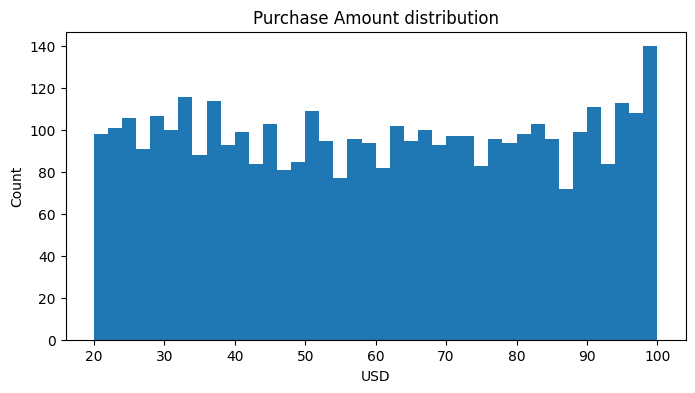

In [9]:
plt.figure(figsize=(8,4))
plt.hist(df['Purchase Amount (USD)'], bins=40)
plt.title('Purchase Amount distribution')
plt.xlabel('USD')
plt.ylabel('Count')
plt.show()

In [11]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for c in cat_cols:
    print('\n--', c)
    print(df[c].value_counts().head(10))


-- Gender
Gender
Male      2652
Female    1248
Name: count, dtype: int64

-- Item Purchased
Item Purchased
Blouse        171
Pants         171
Jewelry       171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Coat          161
Sunglasses    161
Belt          161
Name: count, dtype: int64

-- Category
Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64

-- Location
Location
Montana       96
California    95
Idaho         93
Illinois      92
Alabama       89
Minnesota     88
New York      87
Nevada        87
Nebraska      87
Delaware      86
Name: count, dtype: int64

-- Size
Size
M     1755
L     1053
S      663
XL     429
Name: count, dtype: int64

-- Color
Color
Olive     177
Yellow    174
Silver    173
Teal      172
Green     169
Black     167
Cyan      166
Violet    166
Gray      159
Maroon    158
Name: count, dtype: int64

-- Season
Season
Spring    999
Fall      975
Winter    971
Summer    955


In [12]:
df.columns = [c.strip() for c in df.columns]

In [15]:
target = 'Purchase Amount (USD)'
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if target in num_cols:
    num_cols.remove(target)

In [16]:
print('Numerical cols:', num_cols)
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print('Categorical cols:', cat_cols)

Numerical cols: ['Age', 'Review Rating', 'Previous Purchases']
Categorical cols: ['Gender', 'Item Purchased', 'Category', 'Location', 'Size', 'Color', 'Season', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Payment Method', 'Frequency of Purchases']


In [18]:
df.columns = [c.strip() for c in df.columns]

for col in ['Discount Applied', 'Promo Code Used']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower().map({
            'yes': 1, 'no': 0, 'true': 1, 'false': 0
        }).fillna(0).astype(int)

if "Frequency of Purchases" in df.columns:
    df['Frequency of Purchases'] = pd.Categorical(
        df['Frequency of Purchases'],
        categories=['Daily','Weekly','Fortnightly','Monthly','Quarterly','Annually'],
        ordered=True
    )

In [19]:
target = "Purchase Amount (USD)"

num_cols = [c for c in df.select_dtypes(include=['int64','float64']).columns if c != target]
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()

print("Numeric:", num_cols)
print("Categorical:", cat_cols)

Numeric: ['Age', 'Review Rating', 'Discount Applied', 'Promo Code Used', 'Previous Purchases']
Categorical: ['Gender', 'Item Purchased', 'Category', 'Location', 'Size', 'Color', 'Season', 'Subscription Status', 'Shipping Type', 'Payment Method', 'Frequency of Purchases']


In [20]:
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (3120, 16) Test: (780, 16)


In [22]:
# %%
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

ordinal_cols = ["Frequency of Purchases"] if "Frequency of Purchases" in X_train.columns else []
nominal_cols = [c for c in cat_cols if c not in ordinal_cols]

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("ordinal", OrdinalEncoder())
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("ord", ordinal_transformer, ordinal_cols),
    ("cat", categorical_transformer, nominal_cols)
])


In [23]:
lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42, n_jobs=-1))
])

In [24]:
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("LR MAE:", mean_absolute_error(y_test, y_pred_lr))
print("LR RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("LR R2:", r2_score(y_test, y_pred_lr))


LR MAE: 20.871147599620507
LR RMSE: 23.964395717889428
LR R2: -0.02628726541463955


In [25]:
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("RF MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RF RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("RF R2:", r2_score(y_test, y_pred_rf))


RF MAE: 21.089487179487183
RF RMSE: 24.205702226054303
RF R2: -0.0470594675401812


In [26]:
param_grid = {
    "regressor__n_estimators": [100, 200],
    "regressor__max_depth": [None, 10, 20],
    "regressor__min_samples_split": [2, 5]
}

gs = GridSearchCV(rf_model, param_grid, cv=3, scoring="neg_mean_squared_error", n_jobs=-1)
gs.fit(X_train, y_train)

best_rf = gs.best_estimator_
y_pred_best = best_rf.predict(X_test)

print("Best Params:", gs.best_params_)
print("Tuned RF MAE:", mean_absolute_error(y_test, y_pred_best))
print("Tuned RF RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best)))
print("Tuned RF R2:", r2_score(y_test, y_pred_best))


Best Params: {'regressor__max_depth': 10, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}
Tuned RF MAE: 20.848112303045514
Tuned RF RMSE: 23.803048864986945
Tuned RF R2: -0.012514267473478391


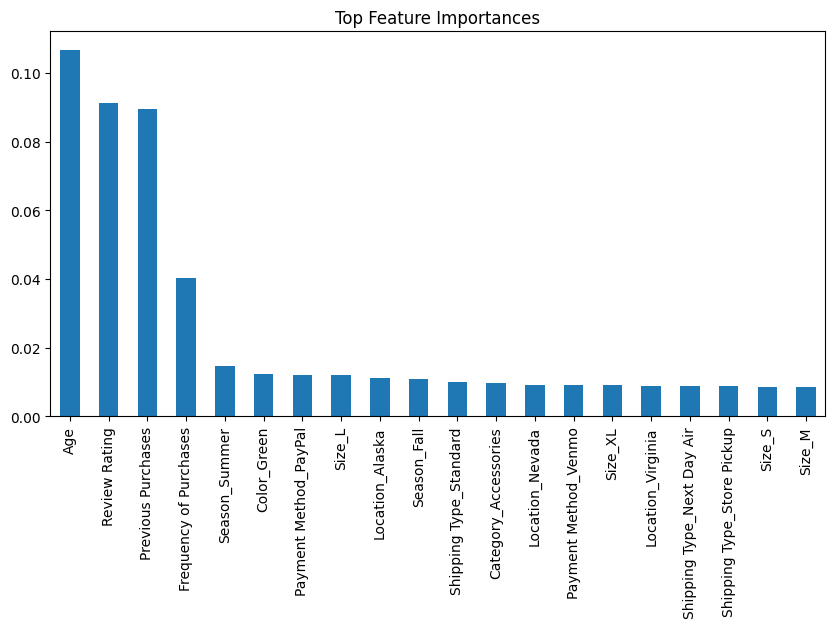

In [27]:
def get_feature_names(ct):
    names = []
    for name, trans, cols in ct.transformers_:
        if name == "num":
            names.extend(cols)
        elif name == "ord":
            names.extend(cols)
        elif name == "cat":
            ohe = trans.named_steps["onehot"]
            names.extend(ohe.get_feature_names_out(cols))
    return names

feature_names = get_feature_names(best_rf.named_steps["preprocessor"])
importances = best_rf.named_steps["regressor"].feature_importances_

fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)[:20]
fi.plot(kind="bar", figsize=(10,5))
plt.title("Top Feature Importances")
plt.show()


In [29]:

joblib.dump(best_rf, r"C:\Users\deves\Downloads\shopping_behavior_updated.csv")
print("Model saved successfully.")


Model saved successfully.


In [31]:
pred_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred_best,
    "error": y_test - y_pred_best
})

pred_df.to_csv(r"C:\Users\deves\Downloads\shopping_behavior_updated.csv", index=False)
print("Predictions saved.")


Predictions saved.


In [32]:
print("---- Summary ----")
print("LR R2:", r2_score(y_test, y_pred_lr))
print("Random Forest (Tuned) R2:", r2_score(y_test, y_pred_best))


---- Summary ----
LR R2: -0.02628726541463955
Random Forest (Tuned) R2: -0.012514267473478391


In [33]:
def predict_single(example_dict):
    model = joblib.load("/mnt/data/best_shopping_model.joblib")
    sample = pd.DataFrame([example_dict])
    return model.predict(sample)[0]